# Round 1 EDA — 18 holes of Pitch & Putt

**File:** `Round 2026-04-09.fit` — 29.5 min, 1768 records

**Ground truth:** 50 shots (18 pitches, 6 chips, 26 putts), score = 50

**Goal:** Explore the time-series, test stroke segmentation, align detected shots against the written log, extract per-shot features, and see how separable the 3 classes are.

In [1]:
import fitparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy import stats

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

In [2]:
# Load the round
fit = fitparse.FitFile('Round 2026-04-09.fit')
rows = [{f.name: f.value for f in r.fields} for r in fit.get_messages('record')]
df = pd.DataFrame(rows).dropna(subset=['peak_mag']).reset_index(drop=True)
df['t'] = (df['timestamp'] - df['timestamp'].iloc[0]).dt.total_seconds()
print(f'{len(df)} records, {df["t"].iloc[-1]:.0f}s ({df["t"].iloc[-1]/60:.1f} min)')
df[['peak_mag','min_mag','mean_mag','std_mag','max_jerk','peak_x','peak_y','peak_z']].describe()

1767 records, 1773s (29.6 min)


,peak_mag,min_mag,mean_mag,std_mag,max_jerk,peak_x,peak_y,peak_z
count,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000
mean,1536.496594,666.609445,1060.379252,247.105427,427.559508,1128.022071,825.072439,722.631013
std,662.327042,225.066093,128.939007,214.656621,457.205778,620.836885,463.793015,644.715273
min,1021.138550,81.957306,836.009460,4.920262,10.539551,59.000000,27.000000,107.000000
25%,1197.893982,478.933701,1014.104736,90.267235,191.307251,787.000000,466.000000,436.000000
50%,1500.104614,656.654419,1034.043823,246.284943,389.273438,1056.000000,823.000000,653.000000
75%,1691.986206,884.666595,1078.482361,359.949738,542.717987,1477.000000,1151.000000,836.000000
max,8981.944336,1010.632996,2488.404053,2215.230957,5813.576172,6812.000000,3744.000000,8021.000000


## 1. Full time-series overview

Plot the entire round — every second of peak_mag, std_mag, and max_jerk. This is the most important plot: it shows the full "fingerprint" of a round.

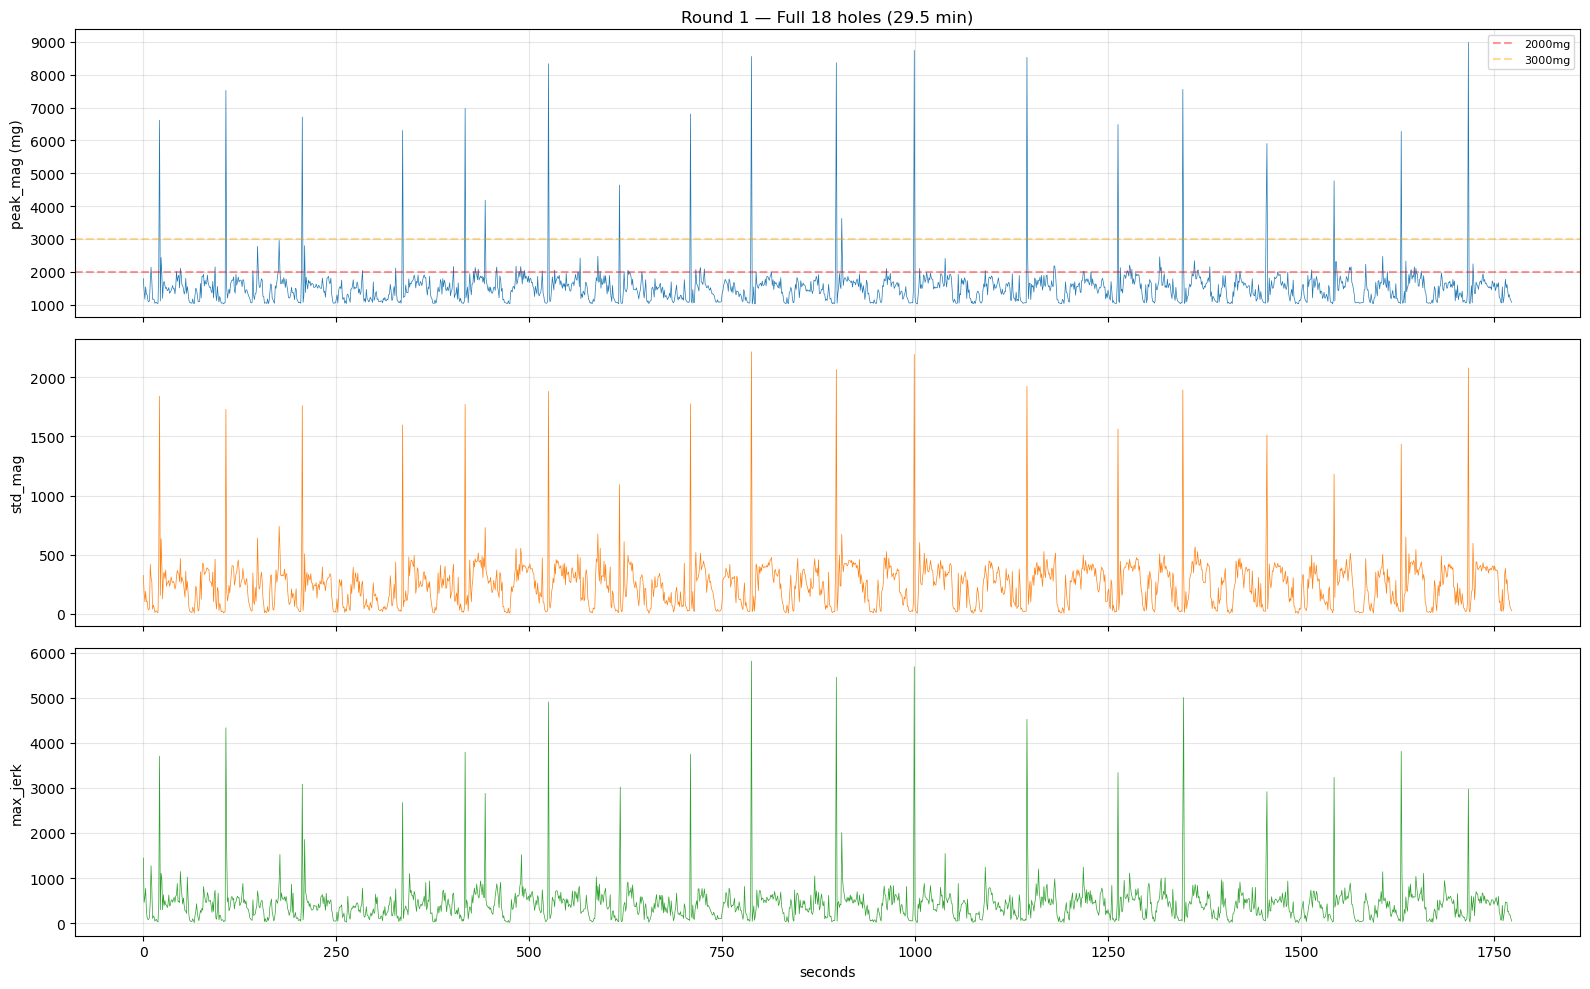

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

axes[0].plot(df['t'], df['peak_mag'], color='C0', linewidth=0.5)
axes[0].axhline(2000, color='red', ls='--', alpha=0.4, label='2000mg')
axes[0].axhline(3000, color='orange', ls='--', alpha=0.4, label='3000mg')
axes[0].set_ylabel('peak_mag (mg)')
axes[0].set_title('Round 1 — Full 18 holes (29.5 min)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(df['t'], df['std_mag'], color='C1', linewidth=0.5)
axes[1].set_ylabel('std_mag')
axes[1].grid(alpha=0.3)

axes[2].plot(df['t'], df['max_jerk'], color='C2', linewidth=0.5)
axes[2].set_ylabel('max_jerk')
axes[2].set_xlabel('seconds')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Ground truth shot log

Define the shot labels from the written log. We'll align these to detected events later.

In [4]:
# Ground truth from written log
hole_log = [
    {'hole': 1,  'shots': ['pitch', 'putt', 'putt']},
    {'hole': 2,  'shots': ['pitch', 'chip', 'putt', 'putt']},
    {'hole': 3,  'shots': ['pitch', 'putt', 'putt', 'putt']},
    {'hole': 4,  'shots': ['pitch', 'putt']},
    {'hole': 5,  'shots': ['pitch', 'putt']},
    {'hole': 6,  'shots': ['pitch', 'putt']},
    {'hole': 7,  'shots': ['pitch', 'putt']},
    {'hole': 8,  'shots': ['pitch']},  # Hole in one!
    {'hole': 9,  'shots': ['pitch', 'putt', 'putt']},
    {'hole': 10, 'shots': ['pitch', 'putt', 'putt']},
    {'hole': 11, 'shots': ['pitch', 'chip', 'putt', 'putt']},
    {'hole': 12, 'shots': ['pitch', 'putt', 'putt']},
    {'hole': 13, 'shots': ['pitch', 'chip', 'putt']},
    {'hole': 14, 'shots': ['pitch', 'chip', 'putt']},
    {'hole': 15, 'shots': ['pitch', 'putt', 'putt']},
    {'hole': 16, 'shots': ['pitch', 'chip']},
    {'hole': 17, 'shots': ['pitch', 'putt', 'putt']},
    {'hole': 18, 'shots': ['pitch', 'chip', 'putt']},
]

total_shots = sum(len(h['shots']) for h in hole_log)
n_pitch = sum(s == 'pitch' for h in hole_log for s in h['shots'])
n_chip = sum(s == 'chip' for h in hole_log for s in h['shots'])
n_putt = sum(s == 'putt' for h in hole_log for s in h['shots'])
print(f'Total: {total_shots} shots — {n_pitch} pitches, {n_chip} chips, {n_putt} putts')
print(f'Score: {total_shots}')

Total: 50 shots — 18 pitches, 6 chips, 26 putts
Score: 50


## 3. Stroke segmentation — rising-edge detector

Apply the segmenter we validated on the labelled files (10 chips at 1500mg, 10 pitches at 3000mg). For a mixed round, we need a single threshold that catches ALL shot types. We'll scan a range of thresholds and compare the detected count against our ground truth of 50.

In [5]:
def segment_rising_edges(series, threshold):
    """Return indices where the signal first crosses above threshold (rising edges)."""
    above = series.values > threshold
    edges = []
    for i in range(len(above)):
        if above[i] and (i == 0 or not above[i-1]):
            edges.append(i)
    return edges

# Threshold scan
print(f'Ground truth: {total_shots} shots\n')
print(f'{"Threshold":>10} {"Detected":>10} {"Diff":>8}')
print('-' * 32)
for thr in range(1100, 3200, 100):
    edges = segment_rising_edges(df['peak_mag'], thr)
    diff = len(edges) - total_shots
    marker = ' <---' if abs(diff) <= 3 else ''
    print(f'{thr:>10} {len(edges):>10} {diff:>+8}{marker}')

Ground truth: 50 shots

 Threshold   Detected     Diff
--------------------------------
      1100        110      +60
      1200        133      +83
      1300        162     +112
      1400        184     +134
      1500        215     +165
      1600        237     +187
      1700        213     +163
      1800        164     +114
      1900        116      +66
      2000         78      +28
      2100         54       +4
      2200         35      -15
      2300         32      -18
      2400         29      -21
      2500         23      -27
      2600         23      -27
      2700         23      -27
      2800         21      -29
      2900         21      -29
      3000         20      -30
      3100         20      -30


In [6]:
# Also try with different features: std_mag and max_jerk
print('Threshold scan on std_mag:')
print(f'{"Threshold":>10} {"Detected":>10} {"Diff":>8}')
print('-' * 32)
for thr in range(100, 1100, 50):
    edges = segment_rising_edges(df['std_mag'], thr)
    diff = len(edges) - total_shots
    marker = ' <---' if abs(diff) <= 3 else ''
    print(f'{thr:>10} {len(edges):>10} {diff:>+8}{marker}')

print()
print('Threshold scan on max_jerk:')
print(f'{"Threshold":>10} {"Detected":>10} {"Diff":>8}')
print('-' * 32)
for thr in range(200, 2200, 100):
    edges = segment_rising_edges(df['max_jerk'], thr)
    diff = len(edges) - total_shots
    marker = ' <---' if abs(diff) <= 3 else ''
    print(f'{thr:>10} {len(edges):>10} {diff:>+8}{marker}')

Threshold scan on std_mag:
 Threshold   Detected     Diff
--------------------------------
       100        123      +73
       150        147      +97
       200        160     +110
       250        180     +130
       300        181     +131
       350        177     +127
       400        154     +104
       450         92      +42
       500         47       -3 <---
       550         32      -18
       600         27      -23
       650         22      -28
       700         20      -30
       750         18      -32
       800         18      -32
       850         18      -32
       900         18      -32
       950         18      -32
      1000         18      -32
      1050         18      -32

Threshold scan on max_jerk:
 Threshold   Detected     Diff
--------------------------------
       200        132      +82
       300        173     +123
       400        203     +153
       500        236     +186
       600        192     +142
       700        132      +82
     

## 4. Visualise detected shots on the time series

Pick the best threshold from above and plot the detected shot events overlaid on the full time series.

Best threshold: 2100mg → 54 detections (target 50, diff +4)


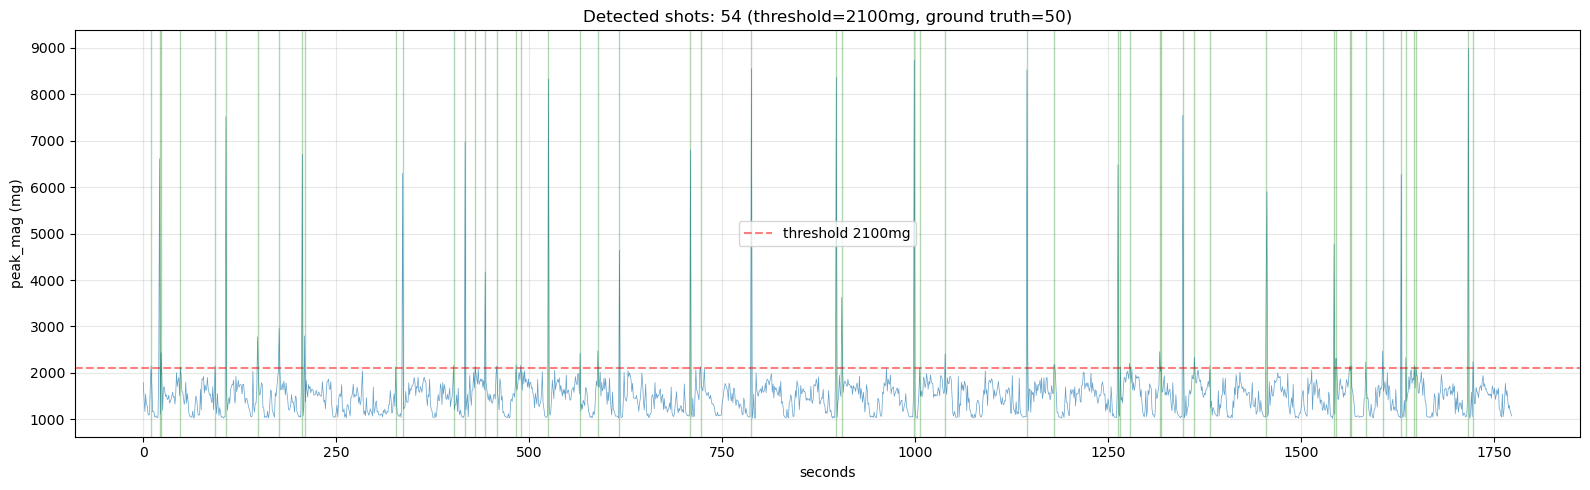

In [7]:
# Pick the threshold closest to 50 detections on peak_mag
# (We'll refine this after visual inspection)
best_thr = None
best_diff = 9999
for thr in range(1100, 3200, 50):
    edges = segment_rising_edges(df['peak_mag'], thr)
    diff = abs(len(edges) - total_shots)
    if diff < best_diff:
        best_diff = diff
        best_thr = thr

edges = segment_rising_edges(df['peak_mag'], best_thr)
print(f'Best threshold: {best_thr}mg → {len(edges)} detections (target {total_shots}, diff {len(edges)-total_shots:+d})')

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
ax.plot(df['t'], df['peak_mag'], color='C0', linewidth=0.5, alpha=0.7)
ax.axhline(best_thr, color='red', ls='--', alpha=0.5, label=f'threshold {best_thr}mg')
for idx in edges:
    ax.axvline(df['t'].iloc[idx], color='green', alpha=0.3, linewidth=1)
ax.set_title(f'Detected shots: {len(edges)} (threshold={best_thr}mg, ground truth={total_shots})')
ax.set_xlabel('seconds')
ax.set_ylabel('peak_mag (mg)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Extract per-shot features

For each detected shot, extract a window of data around the rising edge and compute aggregated features.

In [8]:
def extract_shot_features(df, edge_indices, window_before=1, window_after=2):
    """For each detected rising edge, extract a window and compute features."""
    feature_cols = ['peak_mag', 'min_mag', 'mean_mag', 'std_mag', 'max_jerk', 'peak_x', 'peak_y', 'peak_z']
    shots = []
    for idx in edge_indices:
        start = max(0, idx - window_before)
        end = min(len(df), idx + window_after + 1)
        w = df.iloc[start:end]
        feats = {'edge_idx': idx, 'edge_t': df['t'].iloc[idx]}
        for col in feature_cols:
            if col in w.columns and w[col].notna().any():
                feats[f'{col}_max'] = w[col].max()
                feats[f'{col}_mean'] = w[col].mean()
                feats[f'{col}_std'] = w[col].std()
        shots.append(feats)
    return pd.DataFrame(shots)

shot_df = extract_shot_features(df, edges)
print(f'{len(shot_df)} shots extracted')
shot_df.head(10)

54 shots extracted


,edge_idx,edge_t,peak_mag_max,peak_mag_mean,peak_mag_std,min_mag_max,min_mag_mean,min_mag_std,mean_mag_max,mean_mag_mean,mean_mag_std,std_mag_max,std_mag_mean,std_mag_std,max_jerk_max,max_jerk_mean,max_jerk_std,peak_x_max,peak_x_mean,peak_x_std,peak_y_max,peak_y_mean,peak_y_std,peak_z_max,peak_z_mean,peak_z_std
0,10,10.0,2137.150146,1688.583588,401.083238,982.529419,659.414024,289.088573,1108.057495,1071.154510,37.526978,417.660400,258.781096,159.172026,1272.595947,660.112793,493.136243,1466.0,976.75,368.458388,1853.0,1132.50,698.917973,1176.0,931.75,230.763046
1,21,21.0,6614.448242,3064.053741,2432.497149,851.375916,492.232967,289.620906,1850.988037,1347.380371,398.725139,1839.195190,762.033009,744.219314,3702.763184,1381.324341,1588.122710,4563.0,2315.00,1596.014411,2067.0,1381.50,688.172701,6051.0,2259.75,2595.147828
2,23,23.0,2433.364990,1662.097137,626.518817,788.383179,486.832302,257.701570,1332.453857,1071.123260,192.759847,635.385986,334.054750,239.394859,1106.078247,668.599991,433.719032,2150.0,1405.25,564.527162,2067.0,1033.00,702.403493,1052.0,658.25,351.744581
3,48,48.0,2107.166992,1786.770844,277.200794,835.589600,509.495140,260.254880,1307.879517,1066.426315,166.005615,468.383026,327.215927,96.579811,1145.489502,759.604858,298.775160,1550.0,959.00,678.791573,1621.0,1428.75,241.033020,1324.0,840.50,397.192229
4,93,93.0,2147.812256,1549.601898,449.325160,949.966858,663.884384,328.918001,1146.422607,1050.077576,103.058131,462.487610,214.088122,189.155738,727.121948,387.837891,334.377264,1285.0,1047.25,219.709467,1978.0,1098.25,725.738417,833.0,544.50,277.871073
5,107,107.0,7518.545898,2821.345642,3137.441971,964.366089,780.418091,198.130786,2170.825439,1293.937943,584.694096,1728.903809,515.529596,812.308110,4334.374023,1627.975037,1930.970995,5277.0,1875.50,2272.252994,2082.0,1059.50,799.308660,6583.0,2277.75,2884.510516
6,148,148.0,2776.325928,1995.453979,551.957266,871.651855,678.579834,174.189147,1249.486938,1188.614502,60.935364,640.601501,348.631977,198.584365,712.685669,509.786850,167.513382,1854.0,1610.75,275.730998,1934.0,1031.75,601.953694,1129.0,632.00,353.740960
7,176,176.0,2955.309570,2168.908905,559.160719,528.184631,423.902962,105.108107,1365.865967,1238.205963,136.623266,740.817688,503.843216,183.392647,1522.772217,884.007370,465.043360,2799.0,1839.25,873.012552,1579.0,1333.25,170.286768,882.0,642.00,177.298242
8,206,206.0,6708.258301,2761.500244,2662.524556,964.212097,764.032005,277.676886,2014.533569,1303.071899,477.442972,1759.266846,548.681383,814.133010,3083.473877,993.395813,1403.894747,5185.0,1861.75,2221.751768,1743.0,973.00,600.699037,6165.0,2379.50,2563.221476
9,209,209.0,2795.044189,1813.923737,700.700215,829.338867,596.807205,206.283437,1214.832275,1080.226501,95.558422,507.884583,281.054094,169.397450,1855.319580,880.584839,671.341966,2062.0,1421.75,635.388267,1604.0,1012.25,463.252541,1300.0,712.00,447.518342


## 6. Shot magnitude distribution

Plot the distribution of peak_mag_max across all detected shots. If the 3 shot types (pitch/chip/putt) are separable, we should see distinct modes.

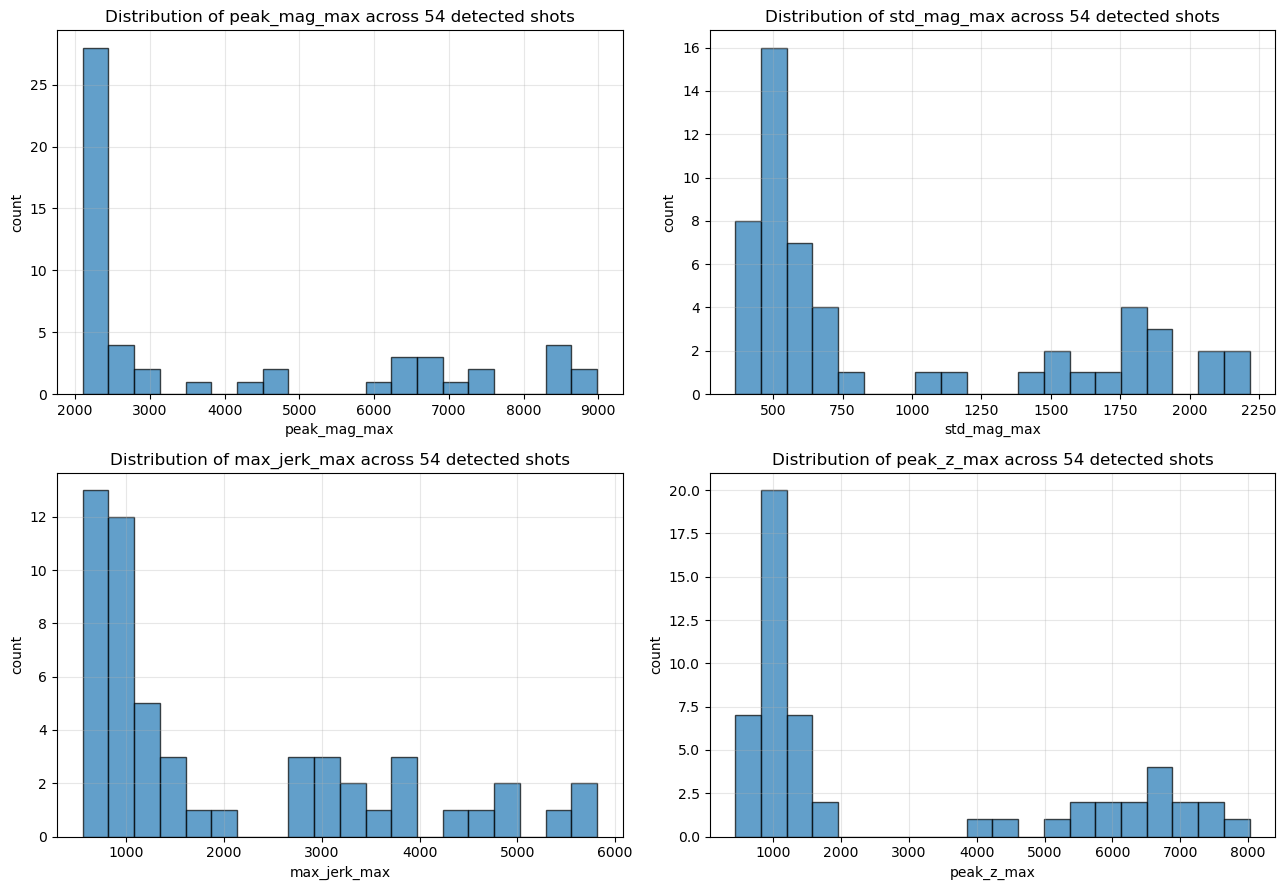

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, feat in zip(axes.flat, ['peak_mag_max', 'std_mag_max', 'max_jerk_max', 'peak_z_max']):
    ax.hist(shot_df[feat].dropna(), bins=20, edgecolor='black', alpha=0.7)
    ax.set_xlabel(feat)
    ax.set_ylabel('count')
    ax.set_title(f'Distribution of {feat} across {len(shot_df)} detected shots')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Inter-shot timing

Time between consecutive detected shots. Holes should show up as long gaps (walking to next tee). Shots within a hole should be close together.

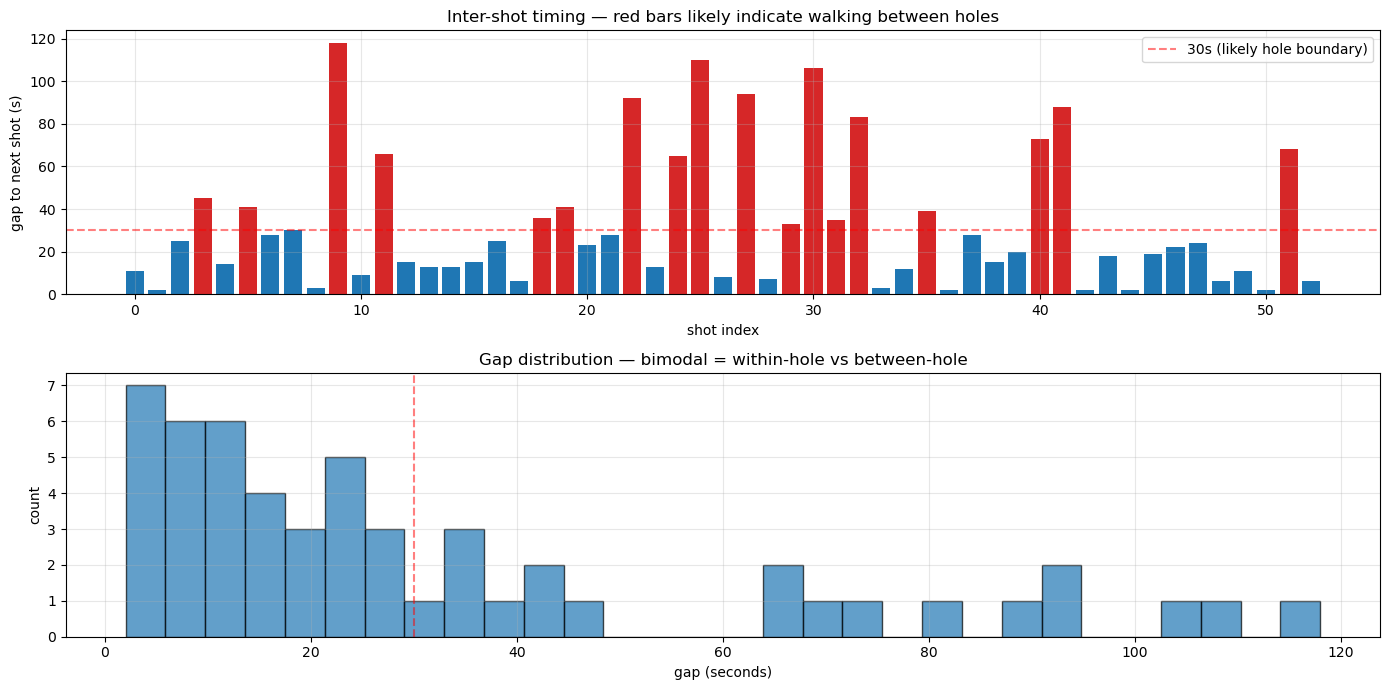

Gaps > 30s: 18 (expected 17 hole transitions for 18 holes)


In [10]:
shot_times = shot_df['edge_t'].values
gaps = np.diff(shot_times)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Gap timeline
axes[0].bar(range(len(gaps)), gaps, color=['C3' if g > 30 else 'C0' for g in gaps])
axes[0].axhline(30, color='red', ls='--', alpha=0.5, label='30s (likely hole boundary)')
axes[0].set_xlabel('shot index')
axes[0].set_ylabel('gap to next shot (s)')
axes[0].set_title('Inter-shot timing — red bars likely indicate walking between holes')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gap histogram
axes[1].hist(gaps, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(30, color='red', ls='--', alpha=0.5)
axes[1].set_xlabel('gap (seconds)')
axes[1].set_ylabel('count')
axes[1].set_title('Gap distribution — bimodal = within-hole vs between-hole')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Count detected hole boundaries
hole_boundaries = np.sum(gaps > 30)
print(f'Gaps > 30s: {hole_boundaries} (expected 17 hole transitions for 18 holes)')

## 8. Attempt automatic hole grouping

Split shots into holes using the long gaps, then compare per-hole shot counts against ground truth.

In [11]:
# Group shots into holes using the gap threshold
def group_into_holes(shot_times, gap_threshold=30):
    holes = []
    current_hole = [0]  # first shot is always hole 1
    for i in range(1, len(shot_times)):
        if shot_times[i] - shot_times[i-1] > gap_threshold:
            holes.append(current_hole)
            current_hole = [i]
        else:
            current_hole.append(i)
    holes.append(current_hole)
    return holes

detected_holes = group_into_holes(shot_times, gap_threshold=30)
print(f'Detected {len(detected_holes)} holes (expected 18)\n')

# Compare against ground truth
print(f'{"Hole":>6} {"Detected":>10} {"Actual":>8} {"Match?":>8}')
print('-' * 36)
matches = 0
for i, (det_hole, gt_hole) in enumerate(zip(detected_holes, hole_log)):
    n_det = len(det_hole)
    n_gt = len(gt_hole['shots'])
    match = 'Y' if n_det == n_gt else 'N'
    if n_det == n_gt:
        matches += 1
    print(f'{i+1:>6} {n_det:>10} {n_gt:>8} {match:>8}')

# Handle case where detected holes != 18
if len(detected_holes) > len(hole_log):
    for i in range(len(hole_log), len(detected_holes)):
        print(f'{"extra":>6} {len(detected_holes[i]):>10} {"???":>8}')
elif len(detected_holes) < len(hole_log):
    for i in range(len(detected_holes), len(hole_log)):
        print(f'{i+1:>6} {"missing":>10} {len(hole_log[i]["shots"]):>8}')

print(f'\nHoles with correct shot count: {matches}/{min(len(detected_holes), len(hole_log))}')

Detected 19 holes (expected 18)

  Hole   Detected   Actual   Match?
------------------------------------
     1          4        3        N
     2          2        4        N
     3          4        4        Y
     4          2        2        Y
     5          7        2        N
     6          1        2        N
     7          3        2        N
     8          2        1        N
     9          1        3        N
    10          2        3        N
    11          2        4        N
    12          1        3        N
    13          1        3        N
    14          1        3        N
    15          3        3        Y
    16          5        2        N
    17          1        3        N
    18         10        3        N
 extra          2      ???

Holes with correct shot count: 3/18


## 9. Per-shot feature scatter — looking for class separation

Before we have per-shot labels aligned, let's see if natural clusters appear in 2D feature space.

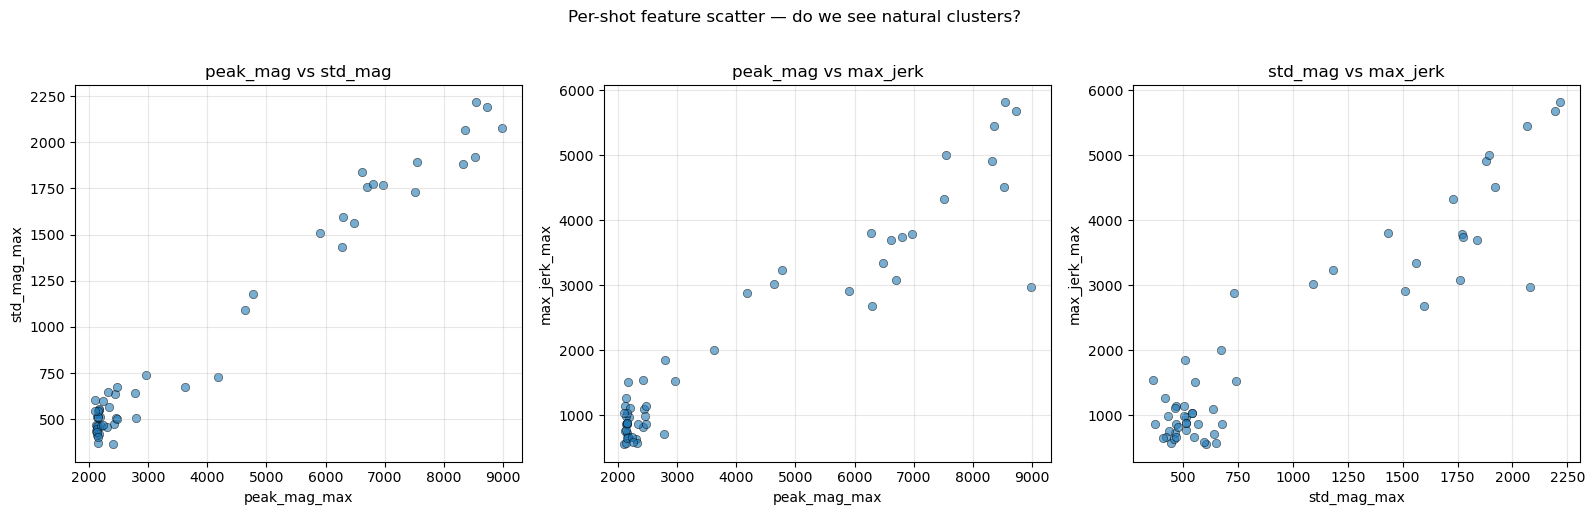

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.scatter(shot_df['peak_mag_max'], shot_df['std_mag_max'], alpha=0.6, edgecolors='black', linewidth=0.5)
ax.set_xlabel('peak_mag_max')
ax.set_ylabel('std_mag_max')
ax.set_title('peak_mag vs std_mag')
ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(shot_df['peak_mag_max'], shot_df['max_jerk_max'], alpha=0.6, edgecolors='black', linewidth=0.5)
ax.set_xlabel('peak_mag_max')
ax.set_ylabel('max_jerk_max')
ax.set_title('peak_mag vs max_jerk')
ax.grid(alpha=0.3)

ax = axes[2]
ax.scatter(shot_df['std_mag_max'], shot_df['max_jerk_max'], alpha=0.6, edgecolors='black', linewidth=0.5)
ax.set_xlabel('std_mag_max')
ax.set_ylabel('max_jerk_max')
ax.set_title('std_mag vs max_jerk')
ax.grid(alpha=0.3)

plt.suptitle('Per-shot feature scatter — do we see natural clusters?', y=1.02)
plt.tight_layout()
plt.show()

## 10. Summary

Key questions this notebook should answer:
1. Does a single peak_mag threshold detect the right number of shots? If not, which feature/threshold combo works best?
2. Can we detect hole boundaries from inter-shot timing alone?
3. Do the 3 shot classes (pitch/chip/putt) form visible clusters in feature space?
4. What are the biggest sources of false positives (walking, bending, etc.)?

Next steps:
- Manually align detected shots to ground-truth labels (using hole grouping + ordering within hole)
- Train a supervised classifier (Random Forest / Gradient Boosting) on the labelled per-shot features
- Test on held-out holes